# Step 1: Authentication

In [ ]:
from google.colab import auth
auth.authenticate_user()
print("Authentication successful!")

Authentication successful!


# Step 2: Get Data

In [ ]:
# Download the file you found using gsutil
!gsutil cp gs://waymo_open_dataset_motion_v_1_3_1/uncompressed/scenario/validation/validation.tfrecord-00000-of-00150 data.tfrecord

import os
if os.path.exists("data.tfrecord"):
    size = os.path.getsize("data.tfrecord")
    print(f"SUCCESS: File downloaded! Size: {size / 1024 / 1024:.2f} MB")
else:
    raise FileNotFoundError("Download failed.")

Copying gs://waymo_open_dataset_motion_v_1_3_1/uncompressed/scenario/validation/validation.tfrecord-00000-of-00150...
==> NOTE: You are downloading one or more large file(s), which would
run significantly faster if you enabled sliced object downloads. This
feature is enabled by default but requires that compiled crcmod be
installed (see "gsutil help crcmod").

\ [1 files][250.5 MiB/250.5 MiB]                                                
Operation completed over 1 objects/250.5 MiB.                                    
SUCCESS: File downloaded! Size: 250.47 MB


# Step 3: Python Configuration

In [ ]:
!pip install waymo-open-dataset-tf-2-12-0 --no-deps
!pip install "protobuf<=3.20.3"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
ydf 0.14.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.3 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobu

# Step 4: Data Process

How to use these new columns in R
Load data
df <- read.csv("waymo_final_dataset.csv")

1. Run your Anomaly Detection (e.g., Mahalanobis Distance)
df$AnomalyScore <- mahalanobis(df[,c("Speed", "YawRate")], ...)

2. Check the "Ground Truth"
Do the agents with High Anomaly Scores also have IsInteractive = TRUE?
boxplot(AnomalyScore ~ IsInteractive, data=df,
        main="Does my model find the interactive agents?",
        col=c("gray", "red"))

If the Red box is higher than the Gray box: Congratulations! Your statistical model successfully detected the agents that Waymo engineers flagged as "Interactive/Important."

In [ ]:
import tensorflow as tf
import math
import pandas as pd
import numpy as np
import sys
import os
from google.colab import files

# --- SETUP ---
sys.path.append("/usr/local/lib/python3.10/dist-packages")
try:
    from waymo_open_dataset.protos import scenario_pb2
except ImportError:
    import importlib
    importlib.reload(sys.modules['google.protobuf'])
    from waymo_open_dataset.protos import scenario_pb2

# --- CONFIGURATION ---
FILENAME = 'data.tfrecord'
print(f"Extracting DATA + BEHAVIORAL FLAGS from: {FILENAME}")

dataset = tf.data.TFRecordDataset(FILENAME, compression_type='')
data_rows = []

count = 0

# Loop through scenarios
for data in dataset:
    proto = scenario_pb2.Scenario()
    proto.ParseFromString(data.numpy())
    sc_id = proto.scenario_id

    # --- GET SPECIAL LISTS (The new stuff) ---
    # These lists contain the IDs of the interesting objects
    interest_ids = set(proto.objects_of_interest)
    predict_ids = set([p.track_index for p in proto.tracks_to_predict])
    sdc_id = proto.sdc_track_index

    # Loop through ALL tracks
    for i, track in enumerate(proto.tracks):

        # --- 1. EXTRACT IDENTIFIERS & FLAGS ---
        agent_id = track.id

        # NEW FLAGS: Check if this agent is in the special lists
        is_sdc = (track.id == sdc_id)
        is_interest = (track.id in interest_ids)  # Waymo says: "This agent is interacting"
        to_predict = (i in predict_ids)           # Waymo says: "Predict this agent"

        # Agent Type
        if track.object_type == 1: agent_type = "Vehicle"
        elif track.object_type == 2: agent_type = "Pedestrian"
        elif track.object_type == 3: agent_type = "Cyclist"
        else: agent_type = "Other"

        # --- 2. EXTRACT CURRENT STATE (Index 10) ---
        state_curr = track.states[10]

        if state_curr.valid:
            pos_x = state_curr.center_x
            pos_y = state_curr.center_y
            heading = state_curr.heading
            length = state_curr.length
            width = state_curr.width
            height = state_curr.height

            # Velocity
            vel_x = state_curr.velocity_x
            vel_y = state_curr.velocity_y
            speed = math.sqrt(vel_x**2 + vel_y**2)

            # Acceleration
            state_prev = track.states[9]
            if state_prev.valid:
                prev_speed = math.sqrt(state_prev.velocity_x**2 + state_prev.velocity_y**2)
                acceleration = (speed - prev_speed) / 0.1

                # Yaw Rate
                yaw_diff = heading - state_prev.heading
                if yaw_diff > math.pi: yaw_diff -= 2*math.pi
                if yaw_diff < -math.pi: yaw_diff += 2*math.pi
                yaw_rate = yaw_diff / 0.1
            else:
                acceleration = None
                yaw_rate = None
        else:
            # Missing data placeholders
            pos_x = None; pos_y = None; heading = None
            length = None; width = None; height = None
            speed = None; acceleration = None; yaw_rate = None
            vel_x = None; vel_y = None

        # --- 3. EXTRACT FUTURE TARGET (Index 60) ---
        state_fut = track.states[60]
        if state_fut.valid and state_curr.valid:
            future_dist = math.sqrt((state_fut.center_x - pos_x)**2 +
                                    (state_fut.center_y - pos_y)**2)
        else:
            future_dist = None

        # --- APPEND ---
        data_rows.append({
            'ScenarioID': sc_id,
            'AgentID': agent_id,
            'AgentType': agent_type,

            # THE NEW FLAGS
            'IsSDC': is_sdc,             # Self Driving Car?
            'IsInteractive': is_interest,# Was this flagged as "Interesting"?
            'ToPredict': to_predict,     # Was this flagged for the Challenge?

            'Valid_Current': state_curr.valid,
            'Valid_Future': state_fut.valid,

            # Kinematics
            'Pos_X': pos_x,
            'Pos_Y': pos_y,
            'Speed': speed,
            'Acceleration': acceleration,
            'YawRate': yaw_rate,
            'Length': length,
            'Width': width,
            'Height': height,
            'Vel_X': vel_x,
            'Vel_Y': vel_y,
            'FutureDist_5s': future_dist
        })

    count += 1
    if count % 20 == 0:
        print(f"Processed {count} scenarios...")

    if count >= 300:
        break

# --- SAVE ---
df = pd.DataFrame(data_rows)
print(f"SUCCESS! Extracted {len(df)} rows.")
df.to_csv('waymo_final_dataset.csv', index=False)
files.download('waymo_final_dataset.csv')

Extracting DATA + BEHAVIORAL FLAGS from: data.tfrecord
Processed 20 scenarios...
Processed 40 scenarios...
Processed 60 scenarios...
Processed 80 scenarios...
Processed 100 scenarios...
Processed 120 scenarios...
Processed 140 scenarios...
Processed 160 scenarios...
Processed 180 scenarios...
Processed 200 scenarios...
Processed 220 scenarios...
Processed 240 scenarios...
Processed 260 scenarios...
Processed 280 scenarios...
SUCCESS! Extracted 18311 rows.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Step 5: Visual/Video

Searching for Scenario (ID: 6c473fa0f3ec89d4)...
Searching... reached index 0
Searching... reached index 20
>>> FOUND TARGET! Index: 24 | ID: 6c473fa0f3ec89d4
Generating animation...
Rendering ALL 90 frames... (This will take ~1 minute)
Generating grid visualization...


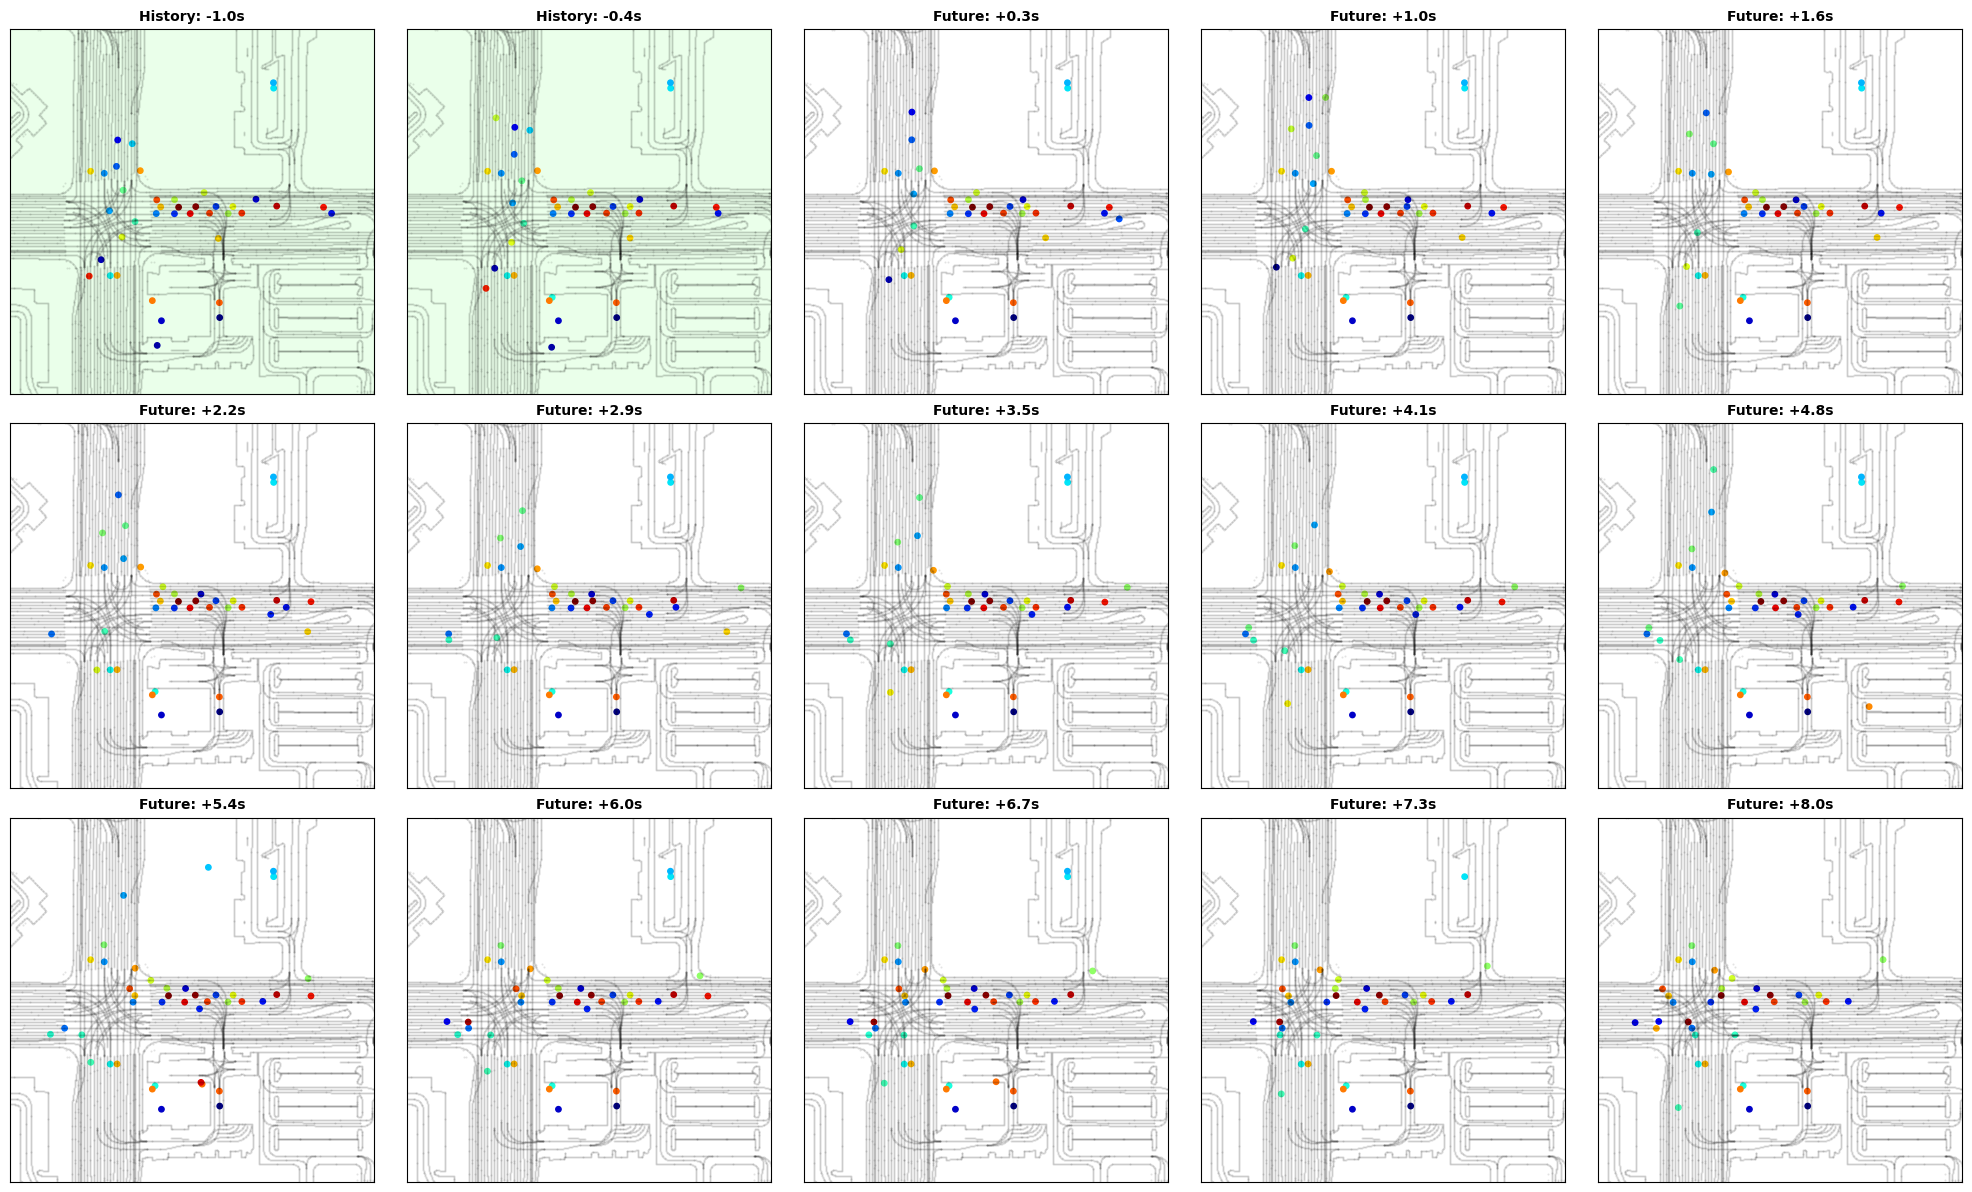

Done! Downloading waymo_vid_6c473fa0f3ec89d4.mp4 and waymo_grid_6c473fa0f3ec89d4.png...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import math
from google.colab import files

# NOTE: This script assumes 'scenario_pb2', 'scenario_to_dict',
# 'generate_full_video_frames', 'get_viewport', and 'get_colormap'
# are already defined in your environment (typical for Waymo OD notebooks).

# --- 1. VISUALIZATION FUNCTION ---

def create_grid_visualization(data, filename="waymo_scenario_grid.png"):
    """
    Generates a static grid of images showing the scenario progression.
    Selects 15 frames evenly spaced from -1.0s to +8.0s.
    """
    rows = 3
    cols = 5
    total_plots = rows * cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, 12))
    axes = axes.flatten()

    # Frame indices: 0 to 89 (10 Past + 80 Future)
    indices = np.linspace(0, 89, total_plots, dtype=int)

    # Data references
    past_x, past_y = data['state/past/x'], data['state/past/y']
    curr_x, curr_y = data['state/current/x'], data['state/current/y']
    fut_x, fut_y = data['state/future/x'], data['state/future/y']

    past_m = data['state/past/valid']
    curr_m = data['state/current/valid']
    fut_m = data['state/future/valid']

    # Viewport calculation
    all_x = np.concatenate([past_x, curr_x, fut_x], axis=1)
    all_y = np.concatenate([past_y, curr_y, fut_y], axis=1)
    all_states = np.stack([all_x, all_y], axis=-1)
    all_mask = np.concatenate([past_m, curr_m, fut_m], axis=1)
    center_y, center_x, width = get_viewport(all_states, all_mask)

    roadgraph = data['roadgraph_samples/xyz']
    color_map = get_colormap(past_x.shape[0])

    print(f"Generating grid visualization...")

    for i, ax in enumerate(axes):
        frame_idx = indices[i]

        if frame_idx < 10:
            # PAST
            time_label = f"History: -{(10-frame_idx)*0.1:.1f}s"
            state = np.stack([past_x[:, frame_idx], past_y[:, frame_idx]], -1)
            mask = past_m[:, frame_idx]
            bg_color = '#eaffea' # Light Green
        else:
            # FUTURE
            fut_idx = frame_idx - 10
            time_label = f"Future: +{(fut_idx+1)*0.1:.1f}s"
            state = np.stack([fut_x[:, fut_idx], fut_y[:, fut_idx]], -1)
            mask = fut_m[:, fut_idx]
            bg_color = 'white'

        # Plot Map
        if len(roadgraph) > 0:
            rg_pts = roadgraph[:, :2].T
            ax.plot(rg_pts[0, :], rg_pts[1, :], 'k.', alpha=0.1, ms=1)

        # Plot Agents
        mask_bool = mask > 0
        ax.scatter(state[:, 0][mask_bool], state[:, 1][mask_bool],
                   marker='o', s=15, color=color_map[mask_bool])

        # Styling
        ax.set_title(time_label, fontsize=10, fontweight='bold')
        ax.set_facecolor(bg_color)
        size = max(10, width * 1.2)
        ax.set_xlim([center_x - size/2, center_x + size/2])
        ax.set_ylim([center_y - size/2, center_y + size/2])
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])

        # Highlight the "Current" moment
        if 9 <= frame_idx <= 11:
            for spine in ax.spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(2)

    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    return filename


# --- 2. EXECUTION & SEARCH ---

FILENAME = 'data.tfrecord'

# USER SETTINGS
TARGET_INDEX = 0             # Option A: By order in file
TARGET_ID = '6c473fa0f3ec89d4' # Option B: By specific ID (set to None to use Index)

if not os.path.exists(FILENAME):
    print(f"Error: {FILENAME} not found.")
else:
    dataset = tf.data.TFRecordDataset(FILENAME, compression_type='')
    found_scenario = None

    print(f"Searching for Scenario (ID: {TARGET_ID if TARGET_ID else 'Index ' + str(TARGET_INDEX)})...")

    for i, raw_data in enumerate(dataset.as_numpy_iterator()):
        temp_proto = scenario_pb2.Scenario()
        temp_proto.ParseFromString(raw_data)
        current_id = temp_proto.scenario_id

        is_target = (current_id == TARGET_ID) if TARGET_ID else (i == TARGET_INDEX)

        if is_target:
            print(f">>> FOUND TARGET! Index: {i} | ID: {current_id}")
            found_scenario = temp_proto
            actual_id = current_id
            break
        elif i % 20 == 0:
            print(f"Searching... reached index {i}")

    if found_scenario:
        # 1. Parse Data
        parsed_data = scenario_to_dict(found_scenario)

        # 2. Generate Video
        print("Generating animation...")
        frames = generate_full_video_frames(parsed_data)
        video_name = f'waymo_vid_{actual_id}.mp4'

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.axis('off')
        im = ax.imshow(frames[0])
        def update(f):
            im.set_data(f)
            return [im]
        ani = animation.FuncAnimation(fig, update, frames=frames, interval=100)
        ani.save(video_name, writer='ffmpeg', fps=10)
        plt.close()

        # 3. Generate Grid
        grid_name = f'waymo_grid_{actual_id}.png'
        create_grid_visualization(parsed_data, filename=grid_name)

        # 4. Download Both
        print(f"Done! Downloading {video_name} and {grid_name}...")
        files.download(video_name)
        files.download(grid_name)
    else:
        print("\nError: Could not find scenario. Check your ID or Index.")

# Draft Sections

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import cm
import matplotlib
import uuid
import sys
import os
from google.colab import files

# --- 1. SETUP IMPORTS ---
sys.path.append("/usr/local/lib/python3.10/dist-packages")
try:
    from waymo_open_dataset.protos import scenario_pb2
except ImportError:
    import importlib
    importlib.reload(sys.modules["google.protobuf"])
    from waymo_open_dataset.protos import scenario_pb2

# --- 2. ANOMALOUS AGENTS FROM R ISOLATION FOREST OUTPUT ---
# (ScenarioID, AgentID, label)
ANOMALOUS_AGENTS = [
    ("909244b878c6c203", 1409,  "Veh 180kmh"),
    ("5baef16beff3351",  1554,  "Veh HighAccel"),
    ("c014d3c05600714f", 560,   "Veh HighSpeed"),
    ("3eea09dc81191856", 998,   "Veh HighYaw"),
    ("bd094f42eeab6700", 510,   "Ped HighSpeed"),
    ("cffef7d3778fc611", 1265,  "Veh HighYaw"),
    ("2c4cec5c3ea292e2", 2861,  "Veh HighYaw"),
    ("27597bc952d2c9c7", 891,   "Veh HighYaw"),
    ("2f8f82f1072ad710", 55,    "Veh HighYaw"),
    ("262112a66742fe8d", 1478,  "Veh HighYaw"),
    ("d3fd8cb194ea76f6", 1093,  "Veh HighYaw"),
    ("262112a66742fe8d", 3661,  "Ped HighYaw"),
    ("e62ae31ead55e09c", 1150,  "Ped Decel"),
    ("308716b64a079919", 1571,  "Veh HighYaw"),
    ("4ba6349a3b92285",  1497,  "Ped HighYaw"),
    ("a2cf10457974619a", 177,   "Ped HighYaw"),
    ("d4a4aac0a880c4a1", 2575,  "Veh HighYaw"),
    ("bec74a69a06a8a83", 408,   "Cyclist HighYaw"),
    ("12d5ce1b476aa6d4", 3729,  "Ped HighYaw"),
    ("e62ae31ead55e09c", 1148,  "Ped HighYaw"),
]

# Build lookup: ScenarioID -> set of AgentIDs
from collections import defaultdict
scenario_to_agents = defaultdict(set)
for scenario_id, agent_id, _ in ANOMALOUS_AGENTS:
    scenario_to_agents[scenario_id].add(agent_id)

TARGET_SCENARIOS = set(scenario_to_agents.keys())

# --- 3. DATA CONVERTER ---
def scenario_to_dict(proto):
    map_points = []
    for feat in proto.map_features:
        poly = []
        if feat.HasField("lane"): poly = feat.lane.polyline
        elif feat.HasField("road_line"): poly = feat.road_line.polyline
        elif feat.HasField("road_edge"): poly = feat.road_edge.polyline
        elif feat.HasField("crosswalk"): poly = feat.crosswalk.polygon
        elif feat.HasField("speed_bump"): poly = feat.speed_bump.polygon
        for p in poly:
            map_points.append([p.x, p.y, p.z])

    if not map_points: map_points = [[0,0,0]]
    roadgraph_xyz = np.array(map_points, dtype=np.float32)
    num_agents = len(proto.tracks)

    past_x = np.zeros((num_agents, 10), dtype=np.float32)
    past_y = np.zeros((num_agents, 10), dtype=np.float32)
    past_valid = np.zeros((num_agents, 10), dtype=np.int64)
    curr_x = np.zeros((num_agents, 1), dtype=np.float32)
    curr_y = np.zeros((num_agents, 1), dtype=np.float32)
    curr_valid = np.zeros((num_agents, 1), dtype=np.int64)
    fut_x = np.zeros((num_agents, 80), dtype=np.float32)
    fut_y = np.zeros((num_agents, 80), dtype=np.float32)
    fut_valid = np.zeros((num_agents, 80), dtype=np.int64)

    for i, track in enumerate(proto.tracks):
        for t in range(10):
            if track.states[t].valid:
                past_x[i, t] = track.states[t].center_x
                past_y[i, t] = track.states[t].center_y
                past_valid[i, t] = 1
        if track.states[10].valid:
            curr_x[i, 0] = track.states[10].center_x
            curr_y[i, 0] = track.states[10].center_y
            curr_valid[i, 0] = 1
        for t in range(80):
            if track.states[11 + t].valid:
                fut_x[i, t] = track.states[11 + t].center_x
                fut_y[i, t] = track.states[11 + t].center_y
                fut_valid[i, t] = 1

    return {
        "roadgraph_samples/xyz": roadgraph_xyz,
        "state/past/x": past_x, "state/past/y": past_y, "state/past/valid": past_valid,
        "state/current/x": curr_x, "state/current/y": curr_y, "state/current/valid": curr_valid,
        "state/future/x": fut_x, "state/future/y": fut_y, "state/future/valid": fut_valid,
    }

# --- 4. PLOTTING FUNCTIONS ---
def create_figure_and_axes(size_pixels):
    fig, ax = plt.subplots(1, 1, num=uuid.uuid4())
    dpi = 100
    size_inches = size_pixels / dpi
    fig.set_size_inches([size_inches, size_inches])
    fig.set_dpi(dpi)
    fig.set_facecolor("white")
    ax.set_facecolor("white")
    ax.axis("off")
    fig.set_tight_layout(True)
    return fig, ax

def fig_canvas_image(fig):
    fig.canvas.draw()
    data = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    w, h = fig.canvas.get_width_height()
    data = data.reshape((h, w, 4))
    return data[:, :, :3]

def get_colormap(num_agents):
    try:
        colors = matplotlib.colormaps["jet"](np.linspace(0, 1, num_agents))
    except:
        colors = cm.get_cmap("jet", num_agents)
        colors = colors(range(num_agents))
    np.random.shuffle(colors)
    return colors

def get_highlighted_colormap(proto, anomalous_agent_ids):
    num_agents = len(proto.tracks)
    colors = np.full((num_agents, 4), [0.6, 0.6, 0.6, 0.4])
    for i, track in enumerate(proto.tracks):
        if track.id in anomalous_agent_ids:
            colors[i] = [1.0, 0.0, 0.0, 1.0]
    return colors

def get_viewport(all_states, all_states_mask):
    valid_states = all_states[all_states_mask > 0]
    if valid_states.shape[0] == 0: return 0, 0, 100
    all_y = valid_states[..., 1]
    all_x = valid_states[..., 0]
    center_y = (np.max(all_y) + np.min(all_y)) / 2
    center_x = (np.max(all_x) + np.min(all_x)) / 2
    width = max(np.ptp(all_y), np.ptp(all_x))
    return center_y, center_x, width

def visualize_one_step(states, mask, roadgraph, title, center_y, center_x, width, color_map, size_pixels=600):
    fig, ax = create_figure_and_axes(size_pixels=size_pixels)
    if len(roadgraph) > 0:
        rg_pts = roadgraph[:, :2].T
        ax.plot(rg_pts[0, :], rg_pts[1, :], "k.", alpha=0.3, ms=1)
    mask_bool = mask > 0
    masked_x = states[:, 0][mask_bool]
    masked_y = states[:, 1][mask_bool]
    colors = color_map[mask_bool]
    ax.scatter(masked_x, masked_y, marker="o", linewidths=3, color=colors)
    ax.set_title(title, fontsize=10)
    size = max(10, width * 1.2)
    ax.axis([center_x - size/2, center_x + size/2, center_y - size/2, center_y + size/2])
    ax.set_aspect("equal")
    image = fig_canvas_image(fig)
    plt.close(fig)
    return image

def generate_full_video_frames(data, color_map=None):
    past_x, past_y = data["state/past/x"], data["state/past/y"]
    curr_x, curr_y = data["state/current/x"], data["state/current/y"]
    fut_x, fut_y = data["state/future/x"], data["state/future/y"]

    all_x = np.concatenate([past_x, curr_x, fut_x], axis=1)
    all_y = np.concatenate([past_y, curr_y, fut_y], axis=1)
    all_states = np.stack([all_x, all_y], axis=-1)

    past_m = data["state/past/valid"]
    curr_m = data["state/current/valid"]
    fut_m = data["state/future/valid"]
    all_mask = np.concatenate([past_m, curr_m, fut_m], axis=1)

    center_y, center_x, width = get_viewport(all_states, all_mask)
    roadgraph = data["roadgraph_samples/xyz"]

    if color_map is None:
        color_map = get_colormap(past_x.shape[0])

    images = []
    for i in range(10):
        time_label = f"History: -{(10-i)*0.1:.1f}s"
        state_snapshot = np.stack([past_x[:, i], past_y[:, i]], -1)
        img = visualize_one_step(state_snapshot, past_m[:, i], roadgraph, time_label, center_y, center_x, width, color_map)
        images.append(img)
    for i in range(80):
        time_label = f"Future: +{(i+1)*0.1:.1f}s"
        state_snapshot = np.stack([fut_x[:, i], fut_y[:, i]], -1)
        img = visualize_one_step(state_snapshot, fut_m[:, i], roadgraph, time_label, center_y, center_x, width, color_map)
        images.append(img)
    return images

def render_and_download(proto, anomalous_ids, video_filename):
    parsed_data = scenario_to_dict(proto)
    color_map = get_highlighted_colormap(proto, anomalous_ids)
    frames = generate_full_video_frames(parsed_data, color_map=color_map)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.axis("off")
    im = ax.imshow(frames[0])

    def update(frame):
        im.set_data(frame)
        return [im]

    ani = animation.FuncAnimation(fig, update, frames=frames, interval=100)
    ani.save(video_filename, writer="ffmpeg", fps=10)
    plt.close()
    files.download(video_filename)
    print(f"Downloaded: {video_filename}")

# --- 5. EXECUTION: ONE PASS, ALL SCENARIOS ---
FILENAME = "data.tfrecord"

if not os.path.exists(FILENAME):
    print("Error: data.tfrecord not found. Run the download step first.")
else:
    print(f"Scanning {FILENAME} for {len(TARGET_SCENARIOS)} target scenarios...")
    dataset = tf.data.TFRecordDataset(FILENAME, compression_type="")

    found = {}
    checked = 0

    for raw in dataset:
        p = scenario_pb2.Scenario()
        p.ParseFromString(raw.numpy())
        checked += 1
        if p.scenario_id in TARGET_SCENARIOS:
            found[p.scenario_id] = p
            print(f"  Found {p.scenario_id} ({len(found)}/{len(TARGET_SCENARIOS)})")
        if len(found) == len(TARGET_SCENARIOS):
            break

    print(f"
Scan complete. Checked {checked} records. Found {len(found)}/{len(TARGET_SCENARIOS)} scenarios.")

    if len(found) < len(TARGET_SCENARIOS):
        missing = TARGET_SCENARIOS - set(found.keys())
        print(f"Missing scenarios (may be in a different shard): {missing}")

    print("
Rendering videos...")
    video_count = 0
    for scenario_id, agent_id, label in ANOMALOUS_AGENTS:
        if scenario_id not in found:
            print(f"Skipping {scenario_id} (not found in this shard)")
            continue
        proto = found[scenario_id]
        video_filename = f"anomaly_{video_count+1:02d}_{label.replace(" ","_")}_{scenario_id[:8]}.mp4"
        print(f"Rendering {video_filename}...")
        render_and_download(proto, {agent_id}, video_filename)
        video_count += 1

    print(f"
Done. {video_count} videos downloaded.")


Reading data.tfrecord...
Visualizing Scenario: ae0532d70d1198c
Rendering ALL 90 frames... (This will take ~1 minute)
Saving waymo_full_video.mp4...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Generating 15 frames for the grid...


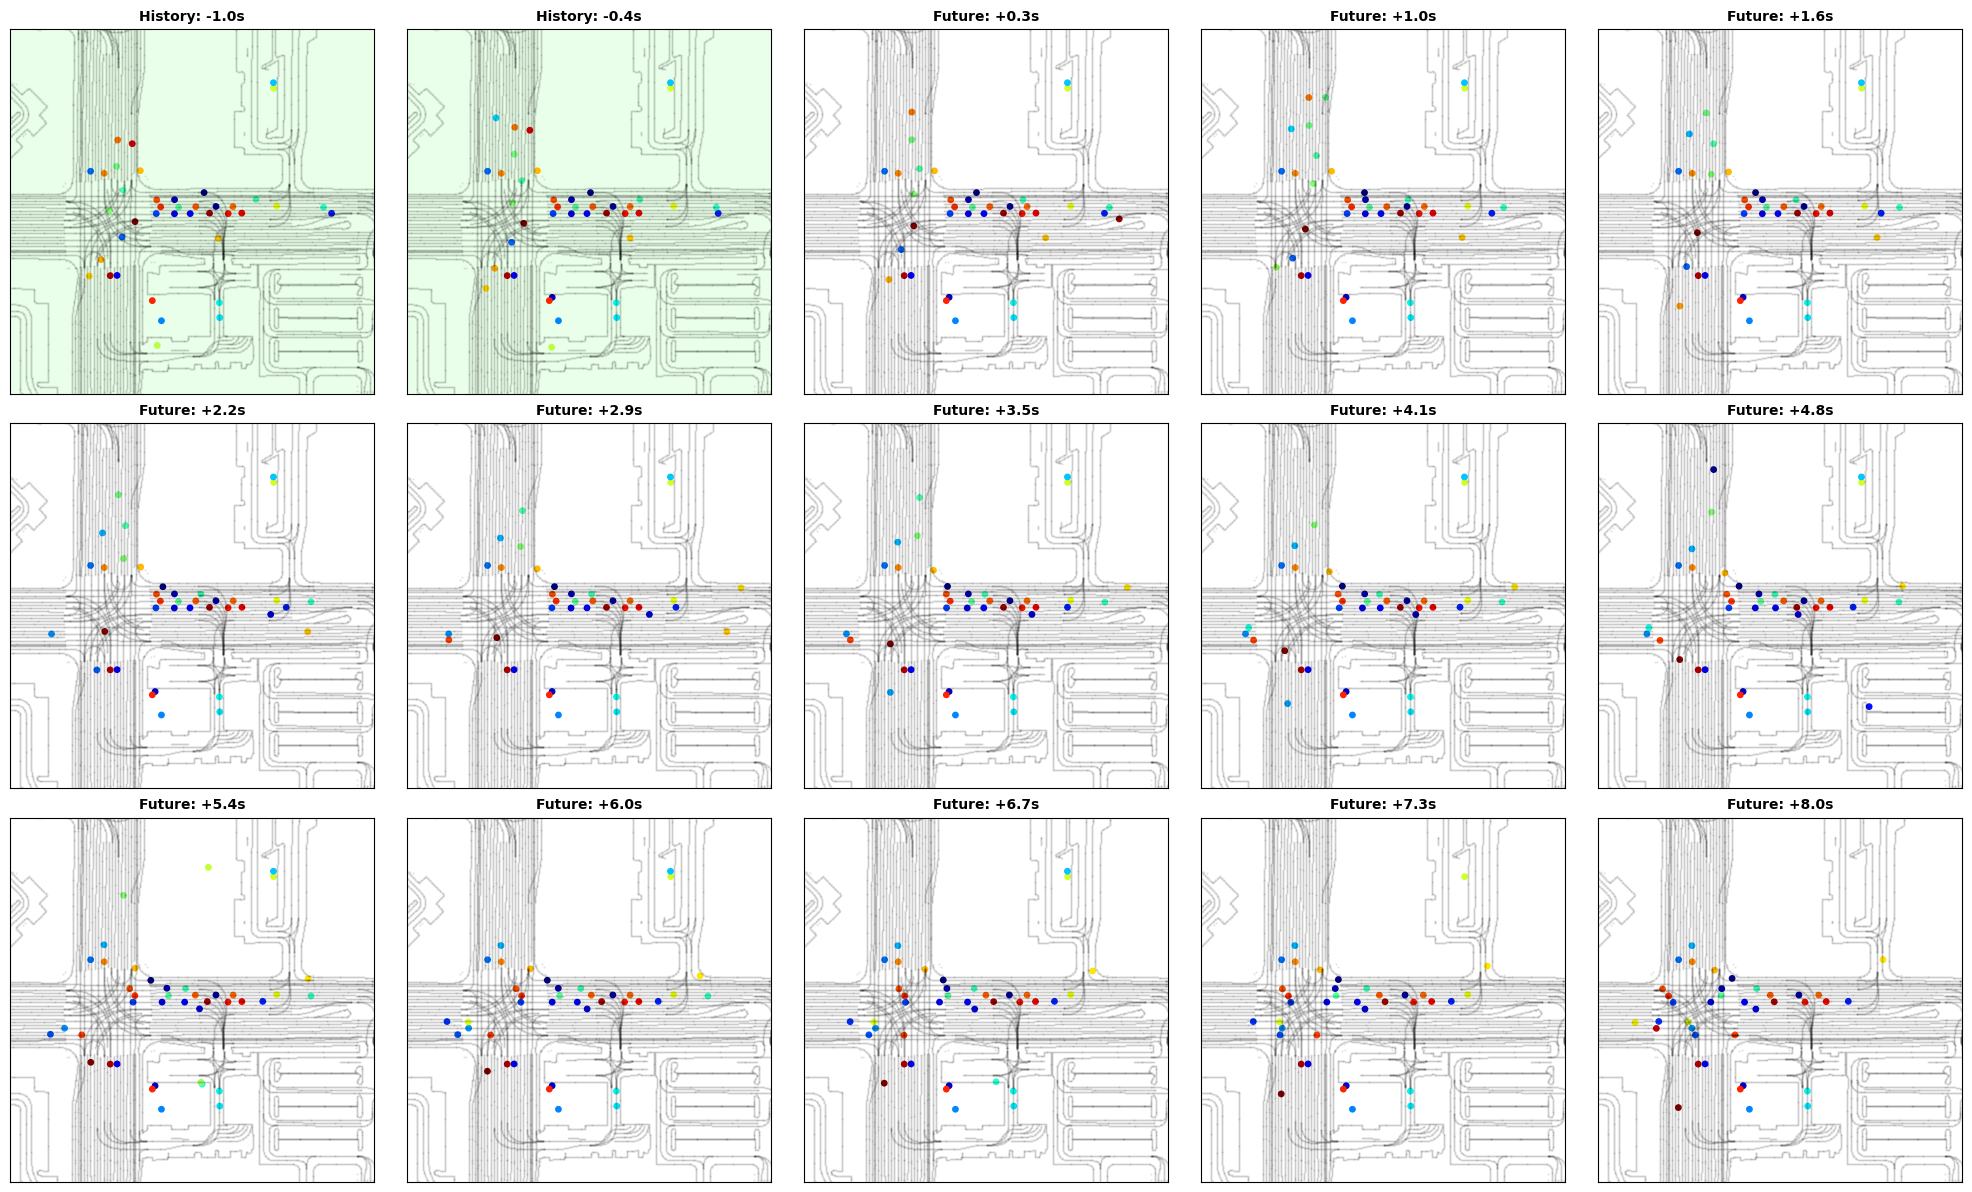

Saved grid to waymo_scenario_grid.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

def create_grid_visualization(data, filename="waymo_scenario_grid.png"):
    """
    Generates a static grid of images showing the scenario progression.
    Selects 15 frames evenly spaced from -1.0s to +8.0s.
    """

    # --- 1. SETUP GRID ---
    rows = 3
    cols = 5
    total_plots = rows * cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, 12))
    axes = axes.flatten()

    # --- 2. CALCULATE INDICES TO PLOT ---
    # We have 90 frames total (10 Past + 80 Future)
    # We want to show the progression.

    # Frame 0 to 9: Past
    # Frame 10 to 89: Future
    # Let's pick indices: 0, 5, 10, 16, 22, ... 89
    indices = np.linspace(0, 89, total_plots, dtype=int)

    # Data references
    past_x, past_y = data['state/past/x'], data['state/past/y']
    curr_x, curr_y = data['state/current/x'], data['state/current/y']
    fut_x, fut_y = data['state/future/x'], data['state/future/y']

    past_m = data['state/past/valid']
    curr_m = data['state/current/valid']
    fut_m = data['state/future/valid']

    # Viewport (calculated once for consistency)
    all_x = np.concatenate([past_x, curr_x, fut_x], axis=1)
    all_y = np.concatenate([past_y, curr_y, fut_y], axis=1)
    all_states = np.stack([all_x, all_y], axis=-1)
    all_mask = np.concatenate([past_m, curr_m, fut_m], axis=1)
    center_y, center_x, width = get_viewport(all_states, all_mask)

    roadgraph = data['roadgraph_samples/xyz']
    color_map = get_colormap(past_x.shape[0])

    print(f"Generating {total_plots} frames for the grid...")

    # --- 3. LOOP AND PLOT ---
    for i, ax in enumerate(axes):
        frame_idx = indices[i]

        # Determine if this frame is Past or Future
        if frame_idx < 10:
            # PAST
            time_label = f"History: -{(10-frame_idx)*0.1:.1f}s"
            state = np.stack([past_x[:, frame_idx], past_y[:, frame_idx]], -1)
            mask = past_m[:, frame_idx]
            bg_color = '#eaffea' # Light Green background for history
        else:
            # FUTURE (Adjust index)
            fut_idx = frame_idx - 10
            time_label = f"Future: +{(fut_idx+1)*0.1:.1f}s"
            state = np.stack([fut_x[:, fut_idx], fut_y[:, fut_idx]], -1)
            mask = fut_m[:, fut_idx]
            bg_color = 'white' # White background for prediction

        # --- PLOT ON SUBPLOT ---
        # Plot Map
        if len(roadgraph) > 0:
            rg_pts = roadgraph[:, :2].T
            ax.plot(rg_pts[0, :], rg_pts[1, :], 'k.', alpha=0.1, ms=1)

        # Plot Agents
        mask_bool = mask > 0
        masked_x = state[:, 0][mask_bool]
        masked_y = state[:, 1][mask_bool]
        colors = color_map[mask_bool]

        ax.scatter(masked_x, masked_y, marker='o', s=15, color=colors)

        # Styling
        ax.set_title(time_label, fontsize=10, fontweight='bold')
        ax.set_facecolor(bg_color)

        # Fixed Zoom
        size = max(10, width * 1.2)
        ax.set_xlim([center_x - size/2, center_x + size/2])
        ax.set_ylim([center_y - size/2, center_y + size/2])
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])

        # Add border to Current Time (Frame 10 approx) to highlight it
        if 9 <= frame_idx <= 11:
            for spine in ax.spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(2)

    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    print(f"Saved grid to {filename}")
    return filename

# --- EXECUTE ---
if 'parsed_data' in globals():
    grid_file = create_grid_visualization(parsed_data)
    files.download(grid_file)
else:
    print("Error: parsed_data not found. Run the video generation script first!")

In [ ]:
# --- 4. EXECUTION (UPDATED TO SWITCH SCENARIOS) ---

FILENAME = 'data.tfrecord'

# ==========================================
#  USER SETTINGS: CHANGE THESE TO SWITCH!
# ==========================================
# OPTION A: Pick by Index (e.g., 0 = first, 5 = sixth scenario)
TARGET_INDEX = 0

# OPTION B: Pick by ID (Overrides Index if not None)
# Paste an ID from your CSV here (e.g., 'b85e1bd6cc8e74c0')
TARGET_ID = '6c473fa0f3ec89d4'
# ==========================================

if not os.path.exists(FILENAME):
    print("Error: data.tfrecord not found.")
else:
    print(f"Reading {FILENAME}...")
    dataset = tf.data.TFRecordDataset(FILENAME, compression_type='')

    found_scenario = None

    # Loop through the file until we find the target
    print("Searching stream for target...")
    for i, raw_data in enumerate(dataset.as_numpy_iterator()):

        # 1. Parse just enough to check ID
        temp_proto = scenario_pb2.Scenario()
        temp_proto.ParseFromString(raw_data)
        current_id = temp_proto.scenario_id

        # 2. Check criteria
        is_target = False

        if TARGET_ID is not None:
            # Search by String ID
            if current_id == TARGET_ID:
                is_target = True
        elif i == TARGET_INDEX:
            # Search by Index Number
            is_target = True

        # 3. If found, process and stop searching
        if is_target:
            print(f"\n>>> FOUND TARGET! Index: {i} | ID: {current_id}")
            found_scenario = temp_proto
            break
        else:
            if i % 10 == 0: print(f"Skipping index {i} ({current_id})...")

    # --- PROCESS THE FOUND SCENARIO ---
    if found_scenario:
        print("Parsing data structure...")
        parsed_data = scenario_to_dict(found_scenario)

        # Generate Frames
        print("Generating video frames...")
        frames = generate_full_video_frames(parsed_data)

        # Save Video
        video_name = f'waymo_scenario_{TARGET_INDEX}.mp4'
        print(f"Saving {video_name}...")

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.axis('off')
        im = ax.imshow(frames[0])

        def update(frame):
            im.set_data(frame)
            return [im]

        ani = animation.FuncAnimation(fig, update, frames=frames, interval=100)
        ani.save(video_name, writer='ffmpeg', fps=10)
        plt.close()

        print("Downloading...")
        files.download(video_name)
    else:
        print(f"\nError: Could not find scenario. (Max index reached or ID incorrect)")

Reading data.tfrecord...
Searching stream for target...
Skipping index 0 (b85e1bd6cc8e74c0)...
Skipping index 10 (923a0c6bb90f4127)...
Skipping index 20 (1d1f5fa04d938a95)...

>>> FOUND TARGET! Index: 24 | ID: 6c473fa0f3ec89d4
Parsing data structure...
Generating video frames...
Rendering ALL 90 frames... (This will take ~1 minute)
Saving waymo_scenario_0.mp4...
Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>